In [1]:
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
from imblearn.over_sampling import SMOTE
import seaborn as sns
import itertools
from itertools import product
import random
import time


## Load the dataset

In [2]:
# Path
MODELS_DIR    = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

In [3]:
# Training data — use the SMOTE-balanced version
X_train = np.load("../Data/processed/X_train_smote.npy")
y_train = np.load("../Data/processed/y_train_smote.npy")

# Validation data — always from the original split (NO SMOTE)
X_val = np.load("../Data/processed/X_val.npy")
y_val = np.load("../Data/processed/y_val.npy")

# Test data — always from the original split (NO SMOTE)
X_test = np.load("../Data/processed/X_test.npy")
y_test = np.load("../Data/processed/y_test.npy")

In [4]:
# --- Hyperparameters ---
USE_SMOTE   = True
EPOCHS      = 50
PATIENCE    = 5
NUM_CLASSES = len(np.unique(y_train))
SEED        = 42

## Normalize the heartbeat with z-score

Normalization is essential for ECG. It's probably the single biggest thing you can do to improve accuracy beyond model architecture changes.
Why ECG specifically needs it:

Patient-level baseline drift — Every patient has a different resting voltage. A "normal" beat from patient A might peak at 1.2 mV, while patient B's peaks at 0.4 mV. Without normalization, the model learns "patient A = amplitude high" instead of "QRS shape = normal."
Electrode placement differs — Amplitudes vary just based on how sensors are attached, which has nothing to do with arrhythmia class.
Batch normalization inside the network doesn't fully fix this — BN normalizes across the batch, but if entire patient recordings have systematically different scales, the model still picks up on it.

In [5]:
# Normalize with z-score per beat (subtract mean, divide by std)
def zscore(x):
    mean = x.mean(axis=1, keepdims=True) 
    std  = x.std(axis=1, keepdims=True) + 1e-8
    return (x - mean) / std

X_train = zscore(X_train).astype(np.float32)
X_val   = zscore(X_val).astype(np.float32)
X_test  = zscore(X_test).astype(np.float32)

print(f"Train shape: {X_train.shape}, {y_train.shape}")
print(f"Val shape: {X_val.shape}, {y_val.shape}")
print(f"Test shape: {X_test.shape}, {y_test.shape}")


Train shape: (252972, 250), (252972,)
Val shape: (15174, 250), (15174,)
Test shape: (15175, 250), (15175,)


In [6]:
# Reshape for PyTorch Conv1d: (batch, channels=1, length)
X_train = X_train[:, np.newaxis, :]
X_val   = X_val[:,   np.newaxis, :]
X_test  = X_test[:,  np.newaxis, :]

y_train = y_train.astype(np.int64)
y_val   = y_val.astype(np.int64)
y_test  = y_test.astype(np.int64)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Train class distribution: {dict(Counter(y_train.tolist()))}')

Train: (252972, 1, 250) | Val: (15174, 1, 250) | Test: (15175, 1, 250)
Train class distribution: {0: 63243, 1: 63243, 2: 63243, 3: 63243}


## CNN model

In [7]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

In [8]:
# Label names and num classes
LABEL_NAMES = ["N (Normal)", "S (Supravent.)", "V (Ventric.)", "F (Fusion)"]
NUM_CLASSES = 4

In [9]:
# data loader
def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)

In [10]:
# Model definition
class CNNModel(nn.Module):
    def __init__(self, num_classes, dropout_scale=0.5):
        super().__init__()
        s = dropout_scale
        d1, d2, d3, dh = 0.4 * s, 0.6 * s, 0.8 * s, s
        
        self.features = nn.Sequential(
            # wide kernel for QRS complex
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(d1),

            # narrower kernel to capture finer details
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(d2),

            # Fine morphological features
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(d3),

            # Global average pooling to reduce to (batch_size, 128, 1)
            nn.AdaptiveAvgPool1d(1),
        )
            
        # Classifier head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dh),
            nn.Linear(64, num_classes)
        )
        
    # Forward pass
    def forward(self, x):
        return self.classifier(self.features(x))

# Quick sanity check — does it build?
_tmp = CNNModel(NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in _tmp.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}\n')
print(_tmp)
del _tmp

Trainable parameters: 44,228

CNNModel(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.4, inplace=False)
 

In [11]:
# One-epoch training/evaluation function
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    # Metrics accumulators
    total_loss, total_samples, total_correct = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(is_train):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss    = criterion(outputs, yb)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            # Update metrics
            preds = outputs.argmax(dim=1)
            total_loss    += loss.item() * xb.size(0)
            total_samples += yb.size(0)
            total_correct += (preds == yb).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

    # Final metrics
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    f1m      = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, accuracy, f1m, np.array(all_labels), np.array(all_preds)

## Hyperparameter tuning

Train random search combination, evaluate on the validation set, and pick the best by macro F1.
Macro F1 is used instead of accuracy because of the class imbalance. The model that predicts all Normal would score ~80%+ accuracy but fail on arrhythmia detection entirely.

In [12]:
# Search space
LR_GRID         = [1e-4, 1e-3, 1e-2]
BATCH_SIZE_GRID = [64, 128]
DROPOUT_GRID      = [0.2, 0.3, 0.5]
WEIGHT_DECAY_GRID = [0, 1e-4, 1e-3]

N_RANDOM_SAMPLES = 15
TUNING_EPOCHS    = 25
TUNING_PATIENCE  = 5

full_space = list(itertools.product(
    LR_GRID, BATCH_SIZE_GRID, DROPOUT_GRID, WEIGHT_DECAY_GRID
))
random.seed(42)
combos = random.sample(full_space, k=min(N_RANDOM_SAMPLES, len(full_space)))

print(f'Total combinations in full space : {len(full_space)}')

print(f'\nSampled configurations:')
for lr, bs, dp, wd in combos:
    print(f'  lr={lr:.0e}  batch={bs:>3}  dropout={dp}  weight_decay={wd}')

Total combinations in full space : 54

Sampled configurations:
  lr=1e-02  batch= 64  dropout=0.3  weight_decay=0.0001
  lr=1e-04  batch= 64  dropout=0.5  weight_decay=0.0001
  lr=1e-04  batch= 64  dropout=0.2  weight_decay=0.0001
  lr=1e-02  batch=128  dropout=0.2  weight_decay=0.001
  lr=1e-04  batch=128  dropout=0.5  weight_decay=0.001
  lr=1e-04  batch=128  dropout=0.5  weight_decay=0
  lr=1e-04  batch=128  dropout=0.3  weight_decay=0.001
  lr=1e-04  batch= 64  dropout=0.5  weight_decay=0.001
  lr=1e-04  batch= 64  dropout=0.5  weight_decay=0
  lr=1e-02  batch= 64  dropout=0.5  weight_decay=0.0001
  lr=1e-03  batch=128  dropout=0.5  weight_decay=0.0001
  lr=1e-04  batch= 64  dropout=0.3  weight_decay=0.001
  lr=1e-02  batch= 64  dropout=0.2  weight_decay=0.0001
  lr=1e-03  batch=128  dropout=0.2  weight_decay=0
  lr=1e-04  batch= 64  dropout=0.2  weight_decay=0.001


In [ ]:
def train_one_config(lr, batch_size, dropout_scale, weight_decay,
                     max_epochs, patience):
    torch.manual_seed(SEED)

    train_loader_cfg = make_loader(X_train, y_train, batch_size, shuffle=True)
    val_loader_cfg   = make_loader(X_val,   y_val,   batch_size, shuffle=False)

    model = CNNModel(NUM_CLASSES, dropout_scale=dropout_scale).to(device)

    if USE_SMOTE:
        criterion = nn.CrossEntropyLoss()
    else:
        classes = np.unique(y_train)
        weights = compute_class_weight('balanced', classes=classes, y=y_train)
        class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

    # AdamW handles weight decay correctly; equals Adam when wd=0
    optimizer = optim.AdamW(
        model.parameters(), lr=lr, weight_decay=weight_decay
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
    )

    best_val_loss = float('inf')
    best_val_f1   = 0.0
    best_val_acc  = 0.0
    no_improve    = 0
    used_epochs   = 0

    t0 = time.time()
    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader_cfg, criterion, optimizer)
        va_loss, va_acc, va_f1, _, _ = run_epoch(model, val_loader_cfg,   criterion)
        scheduler.step(va_loss)
        used_epochs = epoch

        if va_loss < best_val_loss:
            best_val_loss = va_loss
            best_val_f1   = va_f1
            best_val_acc  = va_acc
            no_improve    = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    return {
        'val_loss': best_val_loss,
        'val_acc':  best_val_acc,
        'val_f1':   best_val_f1,
        'epochs':   used_epochs,
        'seconds':  time.time() - t0,
    }

In [14]:
results = []

print(f'Running {len(combos)} configurations...\n')
header = f'{"#":>3} | {"lr":>7} | {"bs":>4} | {"drop":>5} | {"wd":>7} | {"val loss":>9} | {"val acc":>8} | {"val F1":>7} | {"ep":>3} | {"time":>6}'
print(header)
print('-' * len(header))

for i, (lr, bs, dp, wd) in enumerate(combos, 1):
    r = train_one_config(lr, bs, dp, wd, TUNING_EPOCHS, TUNING_PATIENCE)
    r['lr']            = lr
    r['batch_size']    = bs
    r['dropout']       = dp
    r['weight_decay']  = wd
    results.append(r)
    print(f'{i:>3} | {lr:>7.0e} | {bs:>4} | {dp:>5} | {wd:>7} | '
          f'{r["val_loss"]:>9.4f} | {r["val_acc"]:>8.4f} | '
          f'{r["val_f1"]:>7.4f} | {r["epochs"]:>3d} | {r["seconds"]:>5.0f}s')

tuning_df = pd.DataFrame(results)[
    ['lr', 'batch_size', 'dropout', 'weight_decay',
     'val_loss', 'val_acc', 'val_f1', 'epochs', 'seconds']
]
tuning_df = tuning_df.sort_values('val_f1', ascending=False).reset_index(drop=True)

csv_path = f'{MODELS_DIR}/tuning_results.csv'
tuning_df.to_csv(csv_path, index=False)
print(f'\nResults saved to: {csv_path}')

Running 15 configurations...

  # |      lr |   bs |  drop |      wd |  val loss |  val acc |  val F1 |  ep |   time
--------------------------------------------------------------------------------------
  1 |   1e-02 |   64 |   0.3 |  0.0001 |    0.0807 |   0.9786 |  0.8853 |  18 |   598s
  2 |   1e-04 |   64 |   0.5 |  0.0001 |    0.1243 |   0.9638 |  0.8133 |  25 |   814s
  3 |   1e-04 |   64 |   0.2 |  0.0001 |    0.0974 |   0.9714 |  0.8653 |  18 |   587s
  4 |   1e-02 |  128 |   0.2 |   0.001 |    0.0582 |   0.9835 |  0.9117 |  22 |   421s
  5 |   1e-04 |  128 |   0.5 |   0.001 |    0.1789 |   0.9566 |  0.7984 |  22 |   429s
  6 |   1e-04 |  128 |   0.5 |       0 |    0.1823 |   0.9546 |  0.7859 |  22 |   429s
  7 |   1e-04 |  128 |   0.3 |   0.001 |    0.1470 |   0.9550 |  0.7946 |  22 |   425s
  8 |   1e-04 |   64 |   0.5 |   0.001 |    0.1283 |   0.9640 |  0.8162 |  25 |   820s
  9 |   1e-04 |   64 |   0.5 |       0 |    0.1243 |   0.9638 |  0.8133 |  25 |   821s
 10 |   1e-02

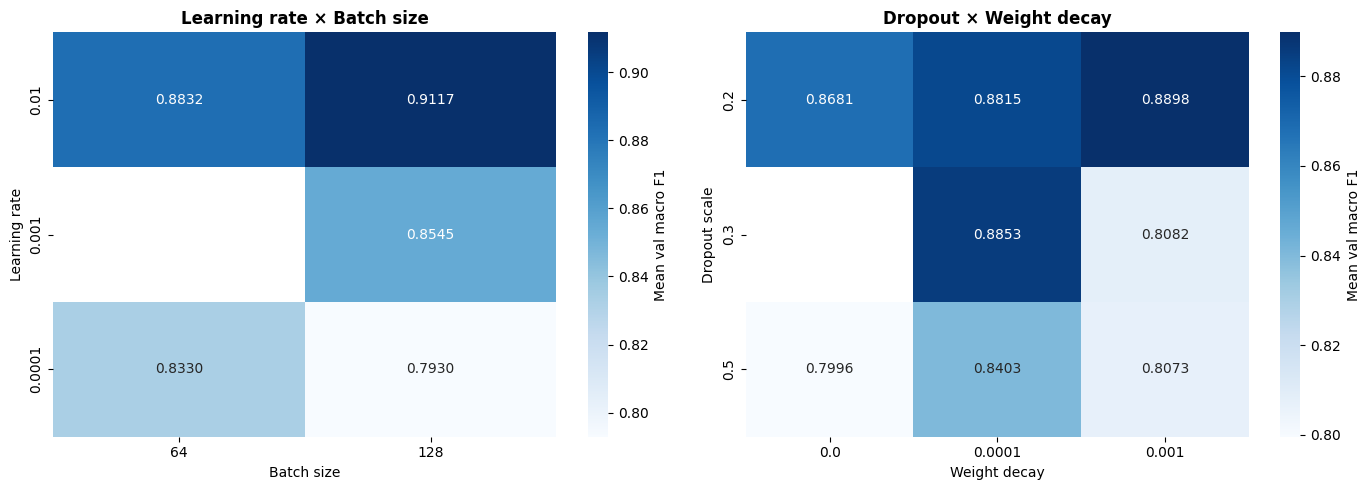

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pv1 = tuning_df.pivot_table(
    index='lr', columns='batch_size', values='val_f1', aggfunc='mean'
).sort_index(ascending=False)
sns.heatmap(pv1, annot=True, fmt='.4f', cmap='Blues', ax=axes[0],
            cbar_kws={'label': 'Mean val macro F1'})
axes[0].set_title('Learning rate × Batch size', fontweight='bold')
axes[0].set_xlabel('Batch size'); axes[0].set_ylabel('Learning rate')

pv2 = tuning_df.pivot_table(
    index='dropout', columns='weight_decay', values='val_f1', aggfunc='mean'
)
sns.heatmap(pv2, annot=True, fmt='.4f', cmap='Blues', ax=axes[1],
            cbar_kws={'label': 'Mean val macro F1'})
axes[1].set_title('Dropout × Weight decay', fontweight='bold')
axes[1].set_xlabel('Weight decay'); axes[1].set_ylabel('Dropout scale')

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/tuning_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
print('Top 5 configurations by validation macro F1:\n')
print(tuning_df.head(5).to_string(index=False))

Top 5 configurations by validation macro F1:

    lr  batch_size  dropout  weight_decay  val_loss  val_acc   val_f1  epochs    seconds
0.0100         128      0.2        0.0010  0.058161 0.983524 0.911654      22 421.123302
0.0100          64      0.2        0.0001  0.069424 0.980954 0.897647      11 357.252354
0.0100          64      0.3        0.0001  0.080654 0.978582 0.885257      18 598.102887
0.0010         128      0.2        0.0000  0.069603 0.979241 0.868062      18 340.436314
0.0001          64      0.2        0.0010  0.097930 0.971003 0.867943      18 589.327689


In [18]:
# Pick the winner
best = tuning_df.iloc[0]
BEST_LR      = float(best['lr'])
BEST_BS      = int(best['batch_size'])
BEST_DROPOUT = float(best['dropout'])
BEST_WD      = float(best['weight_decay'])

print('Best configuration:')
print(f'  Learning rate  : {BEST_LR:.0e}')
print(f'  Batch size     : {BEST_BS}')
print(f'  Dropout scale  : {BEST_DROPOUT}')
print(f'  Weight decay   : {BEST_WD}')
print(f'  Val F1 (macro) : {best["val_f1"]:.4f}')
print(f'  Val accuracy   : {best["val_acc"]:.4f}')

Best configuration:
  Learning rate  : 1e-02
  Batch size     : 128
  Dropout scale  : 0.2
  Weight decay   : 0.001
  Val F1 (macro) : 0.9117
  Val accuracy   : 0.9835


## Final training

In [19]:
# Rebuild loaders, model, loss, optimizer using BEST_LR and BEST_BS
torch.manual_seed(SEED)

train_loader = make_loader(X_train, y_train, BEST_BS, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BEST_BS, shuffle=False)
test_loader  = make_loader(X_test,  y_test,  BEST_BS, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

model = CNNModel(NUM_CLASSES, dropout_scale=BEST_DROPOUT).to(device)

Train batches: 1977
Val batches  : 119
Test batches : 119


In [ ]:
# Loss function with class weights if not using SMOTE
if USE_SMOTE:
    criterion = nn.CrossEntropyLoss()
else:
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weights = torch.tensor(weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

# Adam handles weight decay correctly; equals Adam when wd=0
optimizer = optim.Adam(model.parameters(), lr=BEST_LR, weight_decay=BEST_WD)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-6
)

## Training loop with early stopping

In [25]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
epochs_without_improvement = 0
ckpt_path = f'{MODELS_DIR}/cnn_baseline.pt'

print('Training...\n')
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, va_f1, _, _ = run_epoch(model, val_loader,   criterion)

    scheduler.step(va_loss)

    # Append metrics to history
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    # Check for improvement
    improved = va_loss < best_val_loss
    if improved:
        best_val_loss = va_loss
        epochs_without_improvement = 0
        torch.save(model.state_dict(), ckpt_path)
    else:
        epochs_without_improvement += 1

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'train loss={tr_loss:.4f} acc={tr_acc:.4f} | '
          f'val loss={va_loss:.4f} acc={va_acc:.4f}')

    if epochs_without_improvement >= PATIENCE:
        print(f'\nEarly stopping: no improvement for {PATIENCE} epochs')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

Training...

Epoch   1/50 | train loss=0.3274 acc=0.8775 | val loss=0.6186 acc=0.8057
Epoch   2/50 | train loss=0.3147 acc=0.8833 | val loss=0.6126 acc=0.7885
Epoch   3/50 | train loss=0.3117 acc=0.8847 | val loss=0.4256 acc=0.8420
Epoch   4/50 | train loss=0.3115 acc=0.8855 | val loss=0.2271 acc=0.9495
Epoch   5/50 | train loss=0.3081 acc=0.8865 | val loss=1.5179 acc=0.5341
Epoch   6/50 | train loss=0.3101 acc=0.8865 | val loss=0.2763 acc=0.9366
Epoch   7/50 | train loss=0.3057 acc=0.8873 | val loss=0.2366 acc=0.9373
Epoch   8/50 | train loss=0.3064 acc=0.8878 | val loss=0.7306 acc=0.7337
Epoch   9/50 | train loss=0.3046 acc=0.8883 | val loss=0.5342 acc=0.7812

Early stopping: no improvement for 5 epochs

Best val loss: 0.2271


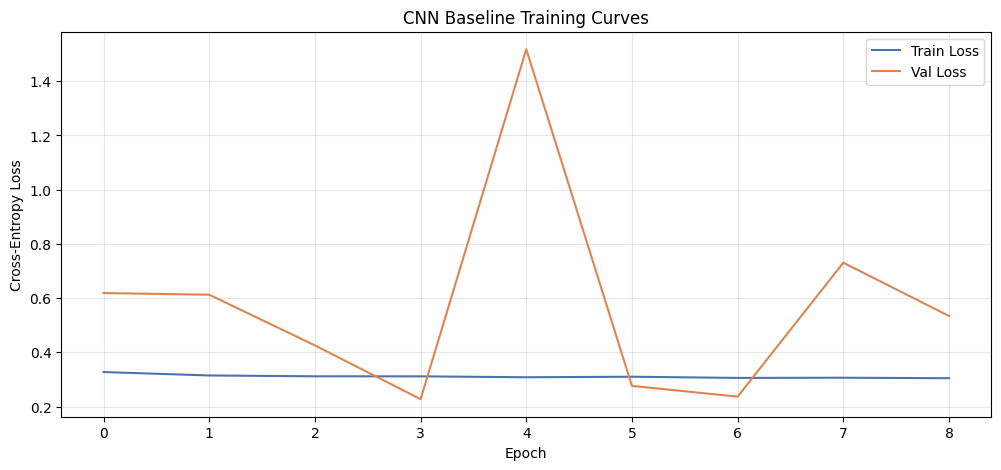

In [26]:
# Training curves
fig = plt.figure(figsize=(12, 5))
plt.plot(history['train_loss'], label='Train Loss', color='#4C72B0')
plt.plot(history['val_loss'], label='Val Loss', color='#DD8452')
set_title = 'CNN Baseline Training Curves'
plt.title(set_title)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

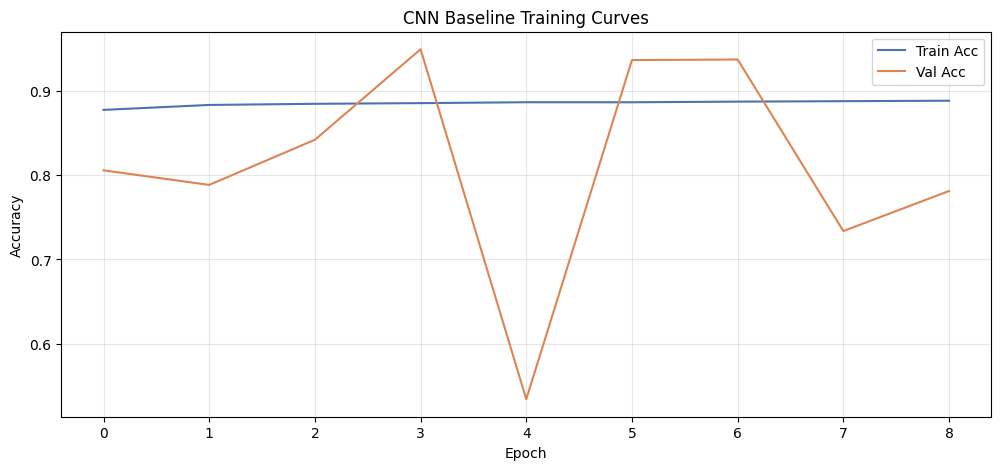

In [27]:
# Training accuracy curves
fig = plt.figure(figsize=(12, 5))
plt.plot(history['train_acc'], label='Train Acc', color='#4C72B0')
plt.plot(history['val_acc'], label='Val Acc', color='#DD8452')
set_title = 'CNN Baseline Training Curves'
plt.title(set_title)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Reload best weights
model.load_state_dict(torch.load(ckpt_path, map_location=device))

test_loss, test_acc, test_f1, y_true, y_pred = run_epoch(model, test_loader, criterion)

print(f'Test loss         : {test_loss:.4f}')
print(f'Test accuracy     : {test_acc:.4f}')
print(f'Test F1 (macro)   : {test_f1:.4f}\n')

report = classification_report(y_true, y_pred, target_names=LABEL_NAMES, digits=4)
print(report)

# Save results
with open(f'{MODELS_DIR}/cnn_baseline_report.txt', 'w') as f:
    f.write(f'CNN Baseline (PyTorch) — use_smote={USE_SMOTE}\n')
    f.write(f'Best config: lr={BEST_LR:.0e}, batch_size={BEST_BS}, '
            f'dropout={BEST_DROPOUT}, weight_decay={BEST_WD}\n')
    f.write('=' * 60 + '\n\n')
    f.write(f'Test loss        : {test_loss:.4f}\n')
    f.write(f'Test accuracy    : {test_acc:.4f}\n')
    f.write(f'Test F1 (macro)  : {test_f1:.4f}\n\n')
    f.write(report)

np.save(f'{MODELS_DIR}/cnn_baseline_history.npy', history, allow_pickle=True)

/var/folders/ds/60p0sjyd6xj_gxb1bv0wknv00000gn/T/ipykernel_9696/423668051.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_path, map

Test loss         : 0.2313
Test accuracy     : 0.9454
Test F1 (macro)   : 0.7104

                precision    recall  f1-score   support

    N (Normal)     0.9853    0.9564    0.9706     13552
S (Supravent.)     0.6737    0.6139    0.6424       417
  V (Ventric.)     0.8235    0.9631    0.8879      1085
    F (Fusion)     0.2258    0.6942    0.3408       121

      accuracy                         0.9454     15175
     macro avg     0.6771    0.8069    0.7104     15175
  weighted avg     0.9591    0.9454    0.9507     15175



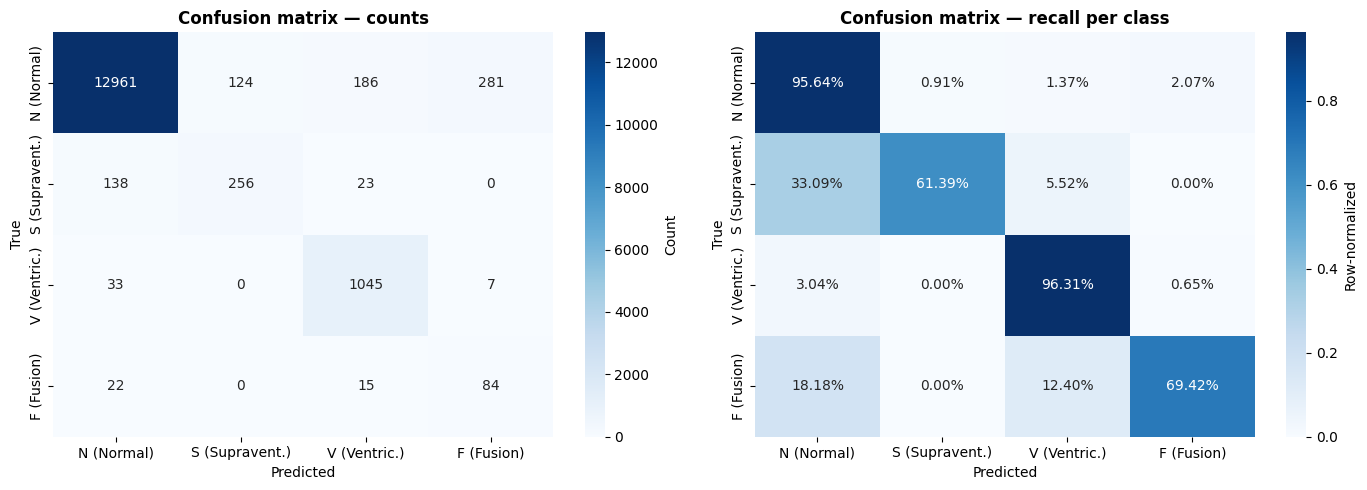

In [ ]:
# Confusion matrix
cm      = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
# Heatmap with annotations, class labels, and colorbar
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion matrix — counts', fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
            cbar_kws={'label': 'Row-normalized'})
axes[1].set_title('Confusion matrix — recall per class', fontweight='bold')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{MODELS_DIR}/cnn_baseline_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

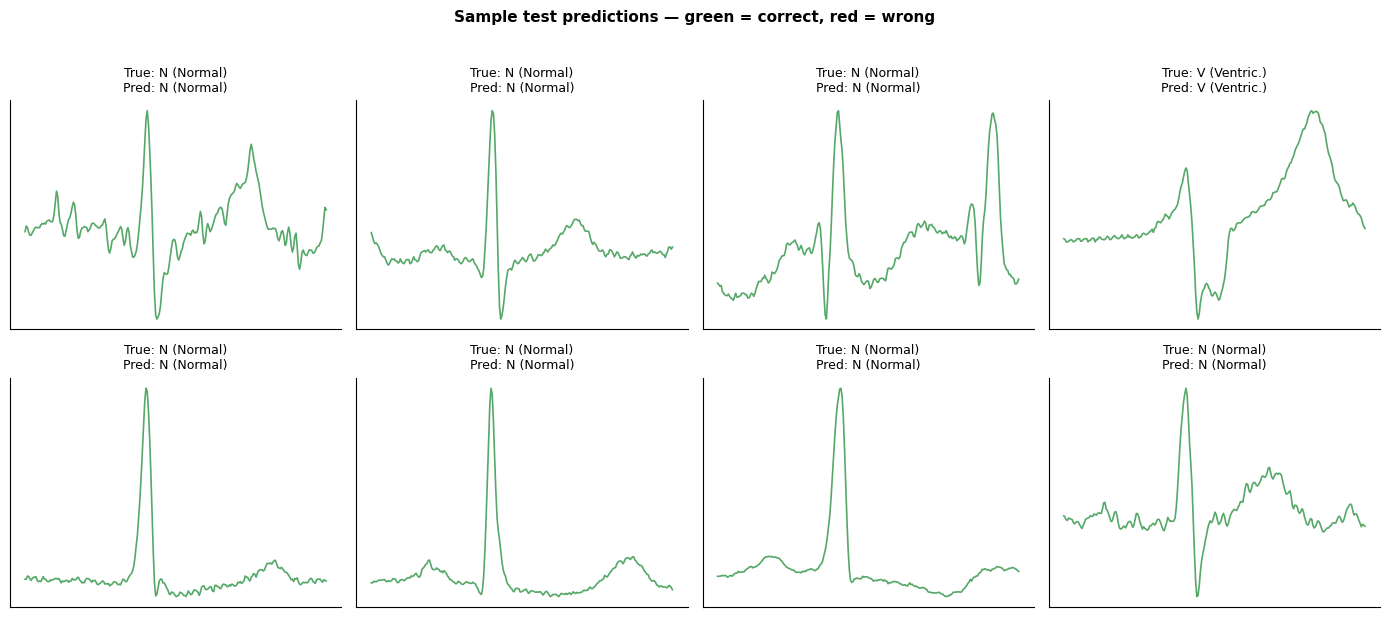

In [31]:
n_show = 8
idxs = random.sample(range(len(y_true)), n_show)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, i in zip(axes.flatten(), idxs):
    beat = X_test[i, 0, :]
    true = LABEL_NAMES[y_true[i]]
    pred = LABEL_NAMES[y_pred[i]]
    color = '#55A868' if y_true[i] == y_pred[i] else '#C44E52'
    ax.plot(beat, color=color, linewidth=1.2)
    ax.set_title(f'True: {true}\nPred: {pred}', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Sample test predictions — green = correct, red = wrong',
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [32]:
summary = tuning_df[
    ['lr', 'batch_size', 'dropout', 'weight_decay', 'val_loss', 'val_acc', 'val_f1']
].copy()
summary['lr'] = summary['lr'].apply(lambda x: f'{x:.0e}')
summary.columns = ['Learning rate', 'Batch size', 'Dropout', 'Weight decay',
                   'Val loss', 'Val accuracy', 'Val macro F1']
print('Hyperparameter search results (sorted by val F1):')
print(summary.to_string(index=False))
print()
print('Best config retrained on full training budget:')
print(f'  Learning rate : {BEST_LR:.0e}')
print(f'  Batch size    : {BEST_BS}')
print(f'  Dropout       : {BEST_DROPOUT}')
print(f'  Weight decay  : {BEST_WD}')
print(f'  Test accuracy : {test_acc:.4f}')
print(f'  Test F1 macro : {test_f1:.4f}')

Hyperparameter search results (sorted by val F1):
Learning rate  Batch size  Dropout  Weight decay  Val loss  Val accuracy  Val macro F1
        1e-02         128      0.2        0.0010  0.058161      0.983524      0.911654
        1e-02          64      0.2        0.0001  0.069424      0.980954      0.897647
        1e-02          64      0.3        0.0001  0.080654      0.978582      0.885257
        1e-03         128      0.2        0.0000  0.069603      0.979241      0.868062
        1e-04          64      0.2        0.0010  0.097930      0.971003      0.867943
        1e-02          64      0.5        0.0001  0.107412      0.976209      0.866753
        1e-04          64      0.2        0.0001  0.097385      0.971398      0.865325
        1e-03         128      0.5        0.0001  0.113196      0.969553      0.840932
        1e-04          64      0.3        0.0010  0.128799      0.958482      0.821840
        1e-04          64      0.5        0.0010  0.128317      0.964017      0.